# FanOut and FanIn (Map-Reduce)

## Map-Reduce Concept

```
START
  ↓
ORCHESTRATOR (splits PDF into chunks)
  ↓ ↓ ↓ ↓ ↓ (parallel)
MAP 0   MAP 1   MAP 2 ... MAP N
  ↓ ↓ ↓ ↓ ↓
REDUCE (merge summaries)
  ↓
END
```

In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send, Command
from langgraph.checkpoint.memory import MemorySaver

In [2]:
# langgraph_mapreduce_wordcount.py
from typing import TypedDict, List, Dict, Annotated
from operator import add

In [3]:
class AggregateState(TypedDict):
    docs: List[str]
    partials: Annotated[List[Dict[str, int]], add]
    final_count: Dict[str, int]
    status_log: str  # <--- Added to track live execution milestones

In [4]:
class WorkerState(TypedDict):
    doc: str

In [5]:
def orchestrator(state: AggregateState) -> Command:
    docs = state.get("docs", []) or []
    sends = [Send("map_doc", {"doc": d}) for d in docs]
    # return a Command that dispatches multiple Sends
    return Command(update={}, goto=sends)

def orchestrator(state: AggregateState) -> Command:
    docs = state.get("docs", []) or []
    sends = [Send("map_doc", {"doc": d}) for d in docs]

    # The engine writes this message to the state FIRST, then triggers the parallel workers
    return Command(
        update={
            "status_log": f"Successfully split PDF into {len(docs)} chunks. Spawning parallel map workers..."
        },
        goto=sends
    )

In [6]:
def map_doc(state: WorkerState) -> Dict[str, List[Dict[str,int]]]:
    text = state.get("doc", "")
    counts: Dict[str,int] = {}
    for token in text.split():
        w = token.lower().strip(".,!?:;\"'()[]")
        if not w:
            continue
        counts[w] = counts.get(w, 0) + 1
    # return as a one-element list under 'partials' so reducer concatenates lists
    return {"partials": [counts]}

In [7]:
def reducer(state: AggregateState) -> Dict[str, Dict[str,int]]:
    final: Dict[str,int] = {}
    for part in state.get("partials", []):
        for word, cnt in part.items():
            final[word] = final.get(word, 0) + cnt
    return {"final_count": final}

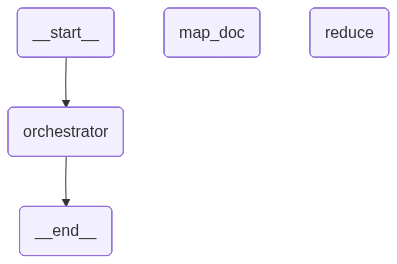

In [8]:
def build_mapreduce_graph() -> StateGraph:
    builder = StateGraph(AggregateState)

    builder.add_node("orchestrator", orchestrator)
    builder.add_node("map_doc", map_doc)
    builder.add_node("reduce", reducer)

    builder.add_edge(START, "orchestrator")
    # map_doc results feed into reduce
    builder.add_edge("map_doc", "reduce")
    builder.add_edge("reduce", END)

    graph = builder.compile(checkpointer=MemorySaver())
    return graph

graph= build_mapreduce_graph()

graph

```
LangGraph graph diagrams do not show dynamic fan-out edges created using Send.
These edges exist only at runtime.
```

### Using `.invoke()`

In [ ]:
if __name__ == "__main__":
    docs= [
        "Peak Performance Gym was founded in 2015 by former Olympic athlete Marcus Chen. With over 15 years of experience in professional athletics, Marcus established the gym to provide personalized fitness solutions for people of all levels. The gym spans 10,000 square feet and features state-of-the-art equipment.",
        "Peak Performance Gym is open Monday through Friday from 5:00 AM to 11:00 PM. On weekends, our hours are 7:00 AM to 9:00 PM. We remain closed on major national holidays. Members with Premium access can enter using their key cards 24/7, including holidays.",
        "Our membership plans include: Basic (₹1,500/month) with access to gym floor and basic equipment; Standard (₹2,500/month) adds group classes and locker facilities; Premium (₹4,000/month) includes 24/7 access, personal training sessions, and spa facilities. We offer student and senior citizen discounts of 15% on all plans. Corporate partnerships are available for companies with 10+ employees joining."
    ]
    initial_state: AggregateState = {
        "docs": docs,
        "partials": [],
        "final_count": {}
    }

    graph = build_mapreduce_graph()
    config = {"configurable": {"thread_id": "mapreduce_example_1"}}

    # invoke the graph (runs the orchestrator -> map -> reduce)
    graph.invoke(initial_state, config=config)

    # get the final StateSnapshot
    snapshot = graph.get_state(config)

    # IMPORTANT: snapshot is a StateSnapshot object — values are in snapshot.values
    final_count = snapshot.values.get("final_count", {})

    print("Final word counts:", final_count)


Final word counts: {'peak': 2, 'performance': 2, 'gym': 5, 'was': 1, 'founded': 1, 'in': 2, '2015': 1, 'by': 1, 'former': 1, 'olympic': 1, 'athlete': 1, 'marcus': 2, 'chen': 1, 'with': 4, 'over': 1, '15': 1, 'years': 1, 'of': 3, 'experience': 1, 'professional': 1, 'athletics': 1, 'established': 1, 'the': 2, 'to': 4, 'provide': 1, 'personalized': 1, 'fitness': 1, 'solutions': 1, 'for': 2, 'people': 1, 'all': 2, 'levels': 1, 'spans': 1, '10,000': 1, 'square': 1, 'feet': 1, 'and': 5, 'features': 1, 'state-of-the-art': 1, 'equipment': 2, 'is': 1, 'open': 1, 'monday': 1, 'through': 1, 'friday': 1, 'from': 1, '5:00': 1, 'am': 2, '11:00': 1, 'pm': 2, 'on': 3, 'weekends': 1, 'our': 2, 'hours': 1, 'are': 2, '7:00': 1, '9:00': 1, 'we': 2, 'remain': 1, 'closed': 1, 'major': 1, 'national': 1, 'holidays': 2, 'members': 1, 'premium': 2, 'access': 3, 'can': 1, 'enter': 1, 'using': 1, 'their': 1, 'key': 1, 'cards': 1, '24/7': 2, 'including': 1, 'membership': 1, 'plans': 2, 'include': 1, 'basic': 2, '₹

### Using `.stream()`

In [ ]:
if __name__ == "__main__":
    docs = [
        "Peak Performance Gym was founded in 2015 by former Olympic athlete Marcus Chen. With over 15 years of experience in professional athletics, Marcus established the gym to provide personalized fitness solutions for people of all levels. The gym spans 10,000 square feet and features state-of-the-art equipment.",
        "Peak Performance Gym is open Monday through Friday from 5:00 AM to 11:00 PM. On weekends, our hours are 7:00 AM to 9:00 PM. We remain closed on major national holidays. Members with Premium access can enter using their key cards 24/7, including holidays.",
        "Our membership plans include: Basic (₹1,500/month) with access to gym floor and basic equipment; Standard (₹2,500/month) adds group classes and locker facilities; Premium (₹4,000/month) includes 24/7 access, personal training sessions, and spa facilities. We offer student and senior citizen discounts of 15% on all plans. Corporate partnerships are available for companies with 10+ employees joining."
    ]

    initial_state: AggregateState = {
        "docs": docs,
        "partials": [],
        "final_count": {}
    }

    graph = build_mapreduce_graph()
    config = {"configurable": {"thread_id": "mapreduce_streaming_1"}}

    print("Starting Map-Reduce Stream Loop...\n")

    # Change .invoke() to .stream() with explicit mode set to values
    # This yields a chunk snapshot every time a node writes back to memory
    for chunk in graph.stream(initial_state, config=config, stream_mode="values"):

        # Extract active values from the current stream chunk
        current_partials = chunk.get("partials", [])
        current_final = chunk.get("final_count", {})

        print(f"Milestone Met -> Active Partials Document Count: {len(current_partials)}")

        # If workers have run but final compilation hasn't occurred yet
        if current_partials and not current_final:
            print(f"   --- Intermediate Buffer State: {current_partials[-1]}\n")

        # If the final reduction step just populated your output key
        if current_final:
            print("   --- Consolidation Step Cleared! ---")

    print("RESULTS:")

    # Optional: fetch state final snapshot to double check
    snapshot = graph.get_state(config)
    final_count = snapshot.values.get("final_count", {})

    print(final_count)

Starting Map-Reduce Stream Loop...

Milestone Met -> Active Partials Document Count: 0
Milestone Met -> Active Partials Document Count: 0
Milestone Met -> Active Partials Document Count: 3
   --- Intermediate Buffer State: {'our': 1, 'membership': 1, 'plans': 2, 'include': 1, 'basic': 2, '₹1,500/month': 1, 'with': 2, 'access': 2, 'to': 1, 'gym': 1, 'floor': 1, 'and': 4, 'equipment': 1, 'standard': 1, '₹2,500/month': 1, 'adds': 1, 'group': 1, 'classes': 1, 'locker': 1, 'facilities': 2, 'premium': 1, '₹4,000/month': 1, 'includes': 1, '24/7': 1, 'personal': 1, 'training': 1, 'sessions': 1, 'spa': 1, 'we': 1, 'offer': 1, 'student': 1, 'senior': 1, 'citizen': 1, 'discounts': 1, 'of': 1, '15%': 1, 'on': 1, 'all': 1, 'corporate': 1, 'partnerships': 1, 'are': 1, 'available': 1, 'for': 1, 'companies': 1, '10+': 1, 'employees': 1, 'joining': 1}

Milestone Met -> Active Partials Document Count: 3
   --- Consolidation Step Cleared! ---
RESULTS:
{'peak': 2, 'performance': 2, 'gym': 5, 'was': 1, 'fo

# Map-Reduce (from PDF)
```
1. Find PDF files in a directory
2. Looping through the files
    2.1. Read the PDF File
    2.2. Get the text and replace new lines
    2.3. Split into chunks
```

In [11]:
import os

from pdfminer.high_level import extract_text

## Load PDFs & split into chunks

In [12]:
def load_pdfs_as_chunks(folder: str, chunk_size: int = 1500) -> List[str]:
    # List files in a directory
    pdf_files = [f for f in os.listdir(folder) if f.lower().endswith(".pdf")]
    print(f"DEBUG: {pdf_files}")

    # Looping through the files
    all_chunks = []
    for pdf in pdf_files:
        path = os.path.join(folder, pdf)
        print(f"Reading PDF: {path}")

        # Get the text and replace new lines
        raw_text = extract_text(path)
        raw_text = raw_text.replace("\n", " ")

        # Split into chunks
        chunks, current = [], []
        words = raw_text.split()

        for w in words:
            current.append(w)
            if len(current) >= chunk_size:
                chunks.append(" ".join(current))
                current = []

        if current:
            chunks.append(" ".join(current))

        print(f" -> extracted {len(chunks)} chunks from {pdf}")
        all_chunks.extend(chunks)

    return all_chunks

In [13]:
class AggregateState(TypedDict, total=False):
    docs: List[str]
    partials: Annotated[List[Dict[str,int]], add]
    final_counts: Dict[str,int]

class WorkerState(TypedDict):
    doc: str

## Orchestrator
1. AggregateState
2. docs = []

## Worker Node
1. WorkerState
2. docs = ""

## Reducer
1. AggregateState
2. Adding all

In [14]:
def orchestrator(state: AggregateState) -> Command:
    docs = state.get("docs", [])
    sends = [Send("map_doc", {"doc": d}) for d in docs]
    return Command(update={}, goto=sends)


In [15]:
def map_doc(state: WorkerState) -> Dict[str, List[Dict[str,int]]]:
    text = state.get("doc", "")
    counts: Dict[str,int] = {}

    for token in text.split():
        # Cleanup
        w = token.lower().strip(".,!?:;\"'()[]")
        if not w:
            continue
        counts[w] = counts.get(w, 0) + 1

    return {"partials": [counts]}  # reducer will merge lists

In [16]:
def reducer(state: AggregateState) -> Dict[str, Dict[str,int]]:
    final: Dict[str,int] = {}
    for part in state.get("partials", []):
        for w, c in part.items():
            final[w] = final.get(w, 0) + c
    return {"final_counts": final}

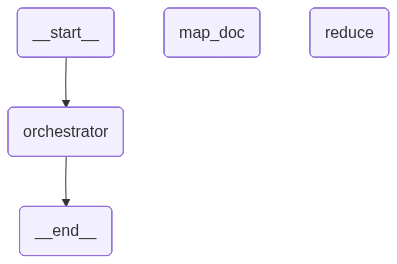

In [17]:
def build_mapreduce_graph() -> StateGraph:
    builder = StateGraph(AggregateState)

    builder.add_node("orchestrator", orchestrator)
    builder.add_node("map_doc", map_doc)
    builder.add_node("reduce", reducer)

    builder.add_edge(START, "orchestrator")
    builder.add_edge("map_doc", "reduce")
    builder.add_edge("reduce", END)

    return builder.compile(checkpointer=MemorySaver())

graph= build_mapreduce_graph()
graph

In [ ]:
if __name__ == "__main__":
    folder = r"/Users/nila/Documents/agents-from-scratch/1 - langgraph-intro/financial_pdfs"

    print("Loading PDFs...")
    docs = load_pdfs_as_chunks(folder, chunk_size=1000)
    print(f"Total chunks for Map-Reduce: {len(docs)}")

    initial_state: AggregateState = {
        "docs": docs,
        "partials": [],
        "final_counts": {}
    }

    graph = build_mapreduce_graph()
    config = {"configurable": {"thread_id": "pdf_mr_wordcount"}}

    graph.invoke(initial_state, config=config)

    snapshot = graph.get_state(config)
    final_counts = snapshot.values.get("final_counts", {})

    print("WORD COUNT:")
    # print top 30 words
    sorted_words = sorted(final_counts.items(), key=lambda x: x[1], reverse=True)
    for w, c in sorted_words[:30]:
        print(f"{w:<20} {c}")


Loading PDFs...
DEBUG: ['JPM_Annual_2023.pdf', 'JPM_SE_Annual_2023.pdf']
Reading PDF: /Users/nila/Documents/agents-from-scratch/1 - langgraph-intro/financial_pdfs/JPM_Annual_2023.pdf
 -> extracted 208 chunks from JPM_Annual_2023.pdf
Reading PDF: /Users/nila/Documents/agents-from-scratch/1 - langgraph-intro/financial_pdfs/JPM_SE_Annual_2023.pdf
 -> extracted 128 chunks from JPM_SE_Annual_2023.pdf
Total chunks for Map-Reduce: 336
WORD COUNT:
the                  16744
and                  11870
–                    10514
of                   9763
to                   7106
in                   5965
a                    3578
for                  3263
$                    2949
as                   2456
on                   2400
is                   2373
risk                 2190
are                  2152
by                   1897
or                   1806
with                 1748
2023                 1732
that                 1635
credit               1596
0                    1450
which  

# Map-Reduce with Timing

Reusing `def load_pdfs_as_chunks()` function<br>
Reusing `def map_doc()` function

In [19]:
import time

In [20]:
class AggregateState(TypedDict, total=False):
    docs: List[str]
    partials: Annotated[List[Dict[str,int]], add]
    final_counts: Dict[str,int]

    # timing fields
    map_start: float
    map_end: float
    reduce_start: float
    reduce_end: float


class WorkerState(TypedDict):
    doc: str

In [21]:
def orchestrator(state: AggregateState) -> Command:
    """Fan-out map tasks"""
    docs = state.get("docs", [])
    sends = [Send("map_doc", {"doc": d}) for d in docs]

    # start MAP phase timer
    return Command(
        update={"map_start": time.time()},
        goto=sends
    )

In [22]:
def reducer(state: AggregateState) -> Dict[str, Dict[str,int]]:
    """Reduce: combine all word counts"""
    final: Dict[str,int] = {}

    # end MAP phase when entering reducer
    reduce_start = time.time()
    update_time = {"reduce_start": reduce_start}

    for part in state.get("partials", []):
        for w, c in part.items():
            final[w] = final.get(w, 0) + c

    # mark REDUCE end
    update_time["reduce_end"] = time.time()

    # also mark MAP end only once (safe)
    if "map_end" not in state:
        update_time["map_end"] = reduce_start

    return {**update_time, "final_counts": final}

In [23]:
def build_mapreduce_graph() -> StateGraph:
    builder = StateGraph(AggregateState)

    builder.add_node("orchestrator", orchestrator)
    builder.add_node("map_doc", map_doc)
    builder.add_node("reduce", reducer)

    builder.add_edge(START, "orchestrator")
    builder.add_edge("map_doc", "reduce")
    builder.add_edge("reduce", END)

    return builder.compile(checkpointer=MemorySaver())

In [24]:
if __name__ == "__main__":
    folder = r"/Users/nila/Documents/agents-from-scratch/1 - langgraph-intro/financial_pdfs"

    print("Loading PDFs...")
    total_start = time.time()
    docs = load_pdfs_as_chunks(folder, chunk_size=1000)
    total_end = time.time()
    total_time = total_end - total_start

    print("\n===============================")
    print("⏱CHUNK TIMING RESULTS")
    print("===============================\n")
    print(f"Chunking time:          {total_time:.4f} seconds\n")
    print(f"Total chunks: {len(docs)}")


    initial_state: AggregateState = {
        "docs": docs,
        "partials": [],
        "final_counts": {}
    }

    graph = build_mapreduce_graph()
    config = {"configurable": {"thread_id": "pdf_mr_timed"}}

    total_start = time.time()
    graph.invoke(initial_state, config=config)
    total_end = time.time()

    snapshot = graph.get_state(config)
    values = snapshot.values

    # Timings
    map_time = values["map_end"] - values["map_start"]
    reduce_time = values["reduce_end"] - values["reduce_start"]
    total_time = total_end - total_start

    print("\n===============================")
    print("⏱MAP-REDUCE TIMING RESULTS")
    print("===============================\n")
    print(f"MAP phase time:      {map_time:.4f} seconds")
    print(f"REDUCE phase time:   {reduce_time:.4f} seconds")
    print(f"TOTAL time:          {total_time:.4f} seconds\n")

    print("Top 30 words:\n")
    final_counts = values["final_counts"]
    for w, c in sorted(final_counts.items(), key=lambda x: x[1], reverse=True)[:30]:
        print(f"{w:<20} {c}")


Loading PDFs...
DEBUG: ['JPM_Annual_2023.pdf', 'JPM_SE_Annual_2023.pdf']
Reading PDF: /Users/nila/Documents/agents-from-scratch/1 - langgraph-intro/financial_pdfs/JPM_Annual_2023.pdf
 -> extracted 208 chunks from JPM_Annual_2023.pdf
Reading PDF: /Users/nila/Documents/agents-from-scratch/1 - langgraph-intro/financial_pdfs/JPM_SE_Annual_2023.pdf
 -> extracted 128 chunks from JPM_SE_Annual_2023.pdf

⏱CHUNK TIMING RESULTS

Chunking time:          65.2386 seconds

Total chunks: 336

⏱MAP-REDUCE TIMING RESULTS

MAP phase time:      0.1003 seconds
REDUCE phase time:   0.0114 seconds
TOTAL time:          0.1163 seconds

Top 30 words:

the                  16744
and                  11870
–                    10514
of                   9763
to                   7106
in                   5965
a                    3578
for                  3263
$                    2949
as                   2456
on                   2400
is                   2373
risk                 2190
are                  215

# Without Map-Reduce

Reusing `def load_pdfs_as_chunks()` Function

In [25]:
def word_count_sequential(chunks: List[str]) -> Dict[str, int]:
    final_counts: Dict[str, int] = {}

    print(f"\nProcessing {len(chunks)} chunks sequentially...")

    for idx, text in enumerate(chunks):
        if idx % 10 == 0:
            print(f"Processing chunk {idx}/{len(chunks)}")

        words = text.split()
        for token in words:
            w = token.lower().strip(".,!?:;\"'()[]")
            if not w:
                continue
            final_counts[w] = final_counts.get(w, 0) + 1

    return final_counts

In [26]:
if __name__ == "__main__":
    folder = r"/Users/nila/Documents/agents-from-scratch/1 - langgraph-intro/financial_pdfs"

    print("Loading PDFs...")
    chunks = load_pdfs_as_chunks(folder, chunk_size=1000)

    print(f"Total chunks for sequential processing: {len(chunks)}")

    start = time.time()
    final_counts = word_count_sequential(chunks)
    end = time.time()

    print("FINAL WORD COUNTS (Sequential)")
    sorted_words = sorted(final_counts.items(), key=lambda x: x[1], reverse=True)

    for w, c in sorted_words[:30]:
        print(f"{w:<20} {c}")

    print("\n⏱TOTAL TIME (Sequential):", round(end - start, 2), "seconds")


Loading PDFs...
DEBUG: ['JPM_Annual_2023.pdf', 'JPM_SE_Annual_2023.pdf']
Reading PDF: /Users/nila/Documents/agents-from-scratch/1 - langgraph-intro/financial_pdfs/JPM_Annual_2023.pdf
 -> extracted 208 chunks from JPM_Annual_2023.pdf
Reading PDF: /Users/nila/Documents/agents-from-scratch/1 - langgraph-intro/financial_pdfs/JPM_SE_Annual_2023.pdf
 -> extracted 128 chunks from JPM_SE_Annual_2023.pdf
Total chunks for sequential processing: 336

Processing 336 chunks sequentially...
Processing chunk 0/336
Processing chunk 10/336
Processing chunk 20/336
Processing chunk 30/336
Processing chunk 40/336
Processing chunk 50/336
Processing chunk 60/336
Processing chunk 70/336
Processing chunk 80/336
Processing chunk 90/336
Processing chunk 100/336
Processing chunk 110/336
Processing chunk 120/336
Processing chunk 130/336
Processing chunk 140/336
Processing chunk 150/336
Processing chunk 160/336
Processing chunk 170/336
Processing chunk 180/336
Processing chunk 190/336
Processing chunk 200/336
Proc

# Sequential Summarizer

# 

In [27]:
from langchain_openai import ChatOpenAI


In [28]:
from dotenv import load_dotenv
load_dotenv(override=True)

llm = ChatOpenAI(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    base_url="https://api.groq.com/openai/v1",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.2
)

In [29]:
def load_pdf_chunks(folder: str, chunk_size: int = 1500):
    files = [f for f in os.listdir(folder) if f.endswith(".pdf")]
    all_chunks = []

    for f in files:
        print(f"Reading PDF: {f}")
        text = extract_text(os.path.join(folder, f)).replace("\n", " ")
        words = text.split()

        chunk, chunks = [], []
        for w in words:
            chunk.append(w)
            if len(chunk) >= chunk_size:
                chunks.append(" ".join(chunk))
                chunk = []
        if chunk:
            chunks.append(" ".join(chunk))

        print(f" → Extracted {len(chunks)} chunks")
        all_chunks.extend(chunks)

    return all_chunks[:5]  # limit for testing

In [30]:
def summarize_chunk(text: str):
    prompt = f"Summarize this text:\n{text}"
    return llm.invoke(prompt).content.strip()

In [31]:
def sequential_summarizer(chunks):
    chunk_summaries = []
    timings = []

    print("\n--- Sequential LLM Summaries ---\n")

    t0 = time.time()

    for i, chunk in enumerate(chunks):
        print(f"Summarizing chunk {i+1}/{len(chunks)} ...")
        start = time.time()
        summary = summarize_chunk(chunk)
        end = time.time()

        chunk_summaries.append(summary)
        timings.append(end - start)

        print(f" → Chunk time: {round(end-start, 2)} sec")

    t1 = time.time()

    # Final merge summary
    merge_start = time.time()
    final_summary = llm.invoke(
        f"Combine these summaries into one:\n\n{chunk_summaries}"
    ).content.strip()
    merge_end = time.time()

    print("\n==============================")
    print("SEQUENTIAL SUMMARY TIMINGS")
    print("==============================")
    print(f"Total chunks: {len(chunks)}")
    print(f"Chunk summarization time: {round(t1 - t0, 2)} sec")
    print(f"Final merge summary time: {round(merge_end - merge_start, 2)} sec")
    print(f"TOTAL Sequential Time:   {round(merge_end - t0, 2)} sec")

    return final_summary


# ------------------------------
# RUN
# ------------------------------
if __name__ == "__main__":
    folder = r"/Users/nila/Documents/agents-from-scratch/1 - langgraph-intro/financial_pdfs"

    chunks = load_pdf_chunks(folder)
    print(f"\nTotal Chunks: {len(chunks)}\n")
    final = sequential_summarizer(chunks)
    print("\nFINAL SUMMARY:\n", final)


Reading PDF: JPM_Annual_2023.pdf
 → Extracted 139 chunks
Reading PDF: JPM_SE_Annual_2023.pdf
 → Extracted 86 chunks

Total Chunks: 5


--- Sequential LLM Summaries ---

Summarizing chunk 1/5 ...
 → Chunk time: 2.06 sec
Summarizing chunk 2/5 ...
 → Chunk time: 1.01 sec
Summarizing chunk 3/5 ...
 → Chunk time: 1.09 sec
Summarizing chunk 4/5 ...
 → Chunk time: 1.14 sec
Summarizing chunk 5/5 ...
 → Chunk time: 1.07 sec

SEQUENTIAL SUMMARY TIMINGS
Total chunks: 5
Chunk summarization time: 6.36 sec
Final merge summary time: 2.16 sec
TOTAL Sequential Time:   8.53 sec

FINAL SUMMARY:
 Here is a comprehensive summary combining the key points from the provided texts:

**JPMorgan Chase's 2023 Performance**

* **Record Revenue:** $162.4 billion (managed revenue) for the sixth consecutive year
* **Net Income:** $49.6 billion
* **Return on Tangible Common Equity (ROTCE):** 21%

**Financial Highlights**

* **Income Statement Data:**
	+ Total Net Revenue: $158,104 million (2023), $128,695 million (202

To clearly see how data transitions and changes shape during a dynamic Map-Reduce lifecycle, let’s simulate a concrete walkthrough.

Imagine you are running your timed script to process a collection of **2 document chunks** ($N=2$). Here is the step-by-step breakdown of what the variables, data structures, and timing fields look like under the hood as they move through the graph.

---

## Step 1: The Initial Entry State (`START`)

You call `graph.invoke(initial_state)`. The global state shared memory space initializes with your data arrays and completely empty placeholders for your analytics and performance trackers:

```python
# The shared AggregateState ledger at START
{
    "docs": [
        "Peak Performance Gym opens early.",  # Chunk 0
        "Performance training helps."         # Chunk 1
    ],
    "partials": [],       # Empty list reducer accumulator
    "final_counts": {},   # Empty final overwrite dictionary
    "map_start": 0.0,
    "map_end": 0.0,
    "reduce_start": 0.0,
    "reduce_end": 0.0
}

```

---

## Step 2: The Routing Control Station (`orchestrator`)

The graph engine activates the `orchestrator` node and passes it the state. The node checks the system clock and builds two runtime routing tasks (`Send`):

1. **The In-Flight Message Transmitted to the Engine:**
The node returns a `Command` object telling the engine to update a global state timestamp and dispatch the workers:


```python
Command(
    update={"map_start": 1716942000.0000}, # e.g., Timestamp at entry
    goto=[
        Send("map_doc", {"doc": "Peak Performance Gym opens early."}),
        Send("map_doc", {"doc": "Performance training helps."})
    ]
)

```


2. **The Resulting Shared State Update:**
The framework instantly logs the `"map_start"` key into global memory. It then shreds the incoming payload and creates two completely isolated execution branches.



---

## Step 3: Parallel Execution Sandbox (`map_doc`)

The two cloned worker tasks run concurrently in separate threads. They are heavily sandboxed: **they cannot see the global timers or each other's data**. They only see their assigned primitive `WorkerState`:

### Branch Task 0 (Processing Chunk 0)

**Input State Received:** `{"doc": "Peak Performance Gym opens early."}` 

* **Internal Calculation:** Clean tokens down to a local frequency map.
* **Returned Output:** 
```python
{"partials": [{"peak": 1, "performance": 1, "gym": 1, "opens": 1, "early": 1}]}
```

### Branch Task 1 (Processing Chunk 1)

**Input State Received:** `{"doc": "Performance training helps."}` 

* **Internal Calculation:** Parse tokens.
* **Returned Output:**
```python
{"partials": [{"performance": 1, "training": 1, "helps": 1}]}
```


---

## Step 4: The Accumulation Layer (State Reducer)

As each parallel worker crosses the finish line, the LangGraph engine stops them at a **Synchronization Barrier**. It grabs their returned arrays and uses the declared state reducer (`operator.add`) to stitch them together sequentially behind the scenes:

$$\text{partials} = \text{Branch}_0[\text{"partials"}] + \text{Branch}_1[\text{"partials"}]$$

Because it performs a standard list concatenation (`list1 + list2`), the global memory space accumulates a clean historical record of every single slice of computation:

```python
# The shared memory payload while waiting at the barrier
{
    "docs": ["Peak Performance Gym opens early.", "Performance training helps."],
    "partials": [
        {"peak": 1, "performance": 1, "gym": 1, "opens": 1, "early": 1}, # Element 0
        {"performance": 1, "training": 1, "helps": 1}                   # Element 1
    ],
    "final_counts": {},
    "map_start": 1716942000.0000,
    "map_end": 0.0,
    ...
}

```

---

## Step 5: Final Evaluation & Consolidation (`reducer`)

Once all parallel tasks report completion, the framework releases the synchronization barrier and activates the single-threaded `reducer` node, handing it the master state compiled above.

1. **Stamping the Transition Timestamps:**
The microsecond the node executes, it pulls the system clock to mark the start of the reduction phase:
```python
reduce_start = 1716942002.5000  # Map phase took exactly 2.5 seconds

```


2. **The Aggregation Loop Processing:**
The function spins through the indices inside `state["partials"]`, adding matching frequencies together item-by-item into a local variable named `final`:


* It scans Element 0: sets `"performance": 1`.
* It scans Element 1: encounters a duplicate instance of `"performance"`, updating its metric balance to `1 + 1 = 2`.




3. **The Data Returned to Memory:**
The node aggregates the local timing tracking properties into an unpacked update dictionary alongside your consolidated word counters:


```python
return {
    "reduce_start": 1716942002.5000,
    "reduce_end": 1716942002.6500,     # Reduction took 0.15 seconds
    "map_end": 1716942002.5000,        # Backpopulates Map completion
    "final_counts": {
        "performance": 2, 
        "peak": 1, 
        "gym": 1, 
        "opens": 1, 
        "early": 1, 
        "training": 1, 
        "helps": 1
    }
}

```



---

## Step 6: Terminal State State Snapshot (`END`)

Because `final_counts` and the timing metrics are not wrapped inside an annotated reducer class within your graph setup, LangGraph drops its default **Overwrite rule**. It overwrites the structural placeholders with your completed calculations and terminates execution at the `END` node.

When you pull `snapshot.values` inside your main python execution script block, you are left with this clean telemetry readout:

```python
# Final state extracted from checkpoint storage
{
    "map_start": 1716942000.0000,
    "map_end": 1716942002.5000,     # Map Phase Duration: 2.50 seconds
    "reduce_start": 1716942002.5000,
    "reduce_end": 1716942002.6500,  # Reduce Phase Duration: 0.15 seconds
    "final_counts": {"performance": 2, "peak": 1, ...}
}

```